## Fase 1: Extracción de Datos Inmobiliarios con Playwright

In [27]:
from playwright.async_api import async_playwright
from pymongo import MongoClient, UpdateOne
import datetime
import random
import re

print("🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...")

cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica'] 

colonias_objetivo = {
    "Condesa": "condesa", "Roma Norte": "roma-norte", "Roma Sur": "roma-sur",
    "Doctores": "doctores", "Del Valle": "del-valle", "Narvarte": "narvarte",
    "Polanco": "polanco", "Coyoacán": "coyoacan", "Santa Fe": "santa-fe",
    "Lomas de Chapultepec": "lomas-de-chapultepec", "San Rafael": "san-rafael",
    "Santa María la Ribera": "santa-maria-la-ribera", "Centro": "centro",
    "Escandón": "escandon", "Portales": "portales"
}

playwright = await async_playwright().start()
browser = await playwright.chromium.launch(
    headless=False,
    args=["--disable-blink-features=AutomationControlled"]
)

contexto = await browser.new_context(viewport={"width": 1366, "height": 768})
page = await contexto.new_page()
await page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

for nombre_colonia, slug in colonias_objetivo.items():
    for pagina in range(1, 4):
        url = f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}.html" if pagina == 1 else f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}-pagina-{pagina}.html"
            
        print(f"⚡ {nombre_colonia} | Pág {pagina}...", end=" ")
        
        try:
            await page.goto(url, timeout=60000)
            
            # Tiempos de espera reducidos pero realistas para evitar el WAF
            await page.wait_for_timeout(random.randint(4000, 7000))
            
            for _ in range(3):
                await page.mouse.wheel(0, 1500)
                await page.wait_for_timeout(1000)
            
            tarjetas = await page.locator("div[class*='postingCard'], div[class*='PostingCard']").all()
            registros_extraidos = []
            
            for tarjeta in tarjetas: 
                try:
                    texto_completo = await tarjeta.inner_text()
                    texto_limpio = texto_completo.lower().replace("\n", " ")
                    
                    # 🧬 REGEX: Precio
                    match_precio = re.search(r'mn\s*([\d,]+)', texto_limpio) or re.search(r'\$\s*([\d,]+)', texto_limpio)
                    if not match_precio: continue
                    precio_numerico = int(match_precio.group(1).replace(',', ''))
                    
                    # 🧬 REGEX: Metros Cuadrados (busca variaciones como 120 m², 120m2, etc.)
                    match_metros = re.search(r'(\d+)\s*(?:m²|m2|m c)', texto_limpio)
                    metros_cuadrados = int(match_metros.group(1)) if match_metros else None
                    
                    # 🧬 REGEX: Recámaras
                    match_recamaras = re.search(r'(\d+)\s*rec', texto_limpio)
                    recamaras = int(match_recamaras.group(1)) if match_recamaras else None
                    
                    titulo = texto_completo.split('\n')[0].strip()[:100]
                    
                    # Solo guardamos el dato si logramos extraer precio y metros cuadrados
                    if metros_cuadrados and precio_numerico: 
                        registros_extraidos.append({
                            "titulo": titulo, 
                            "precio_numerico": precio_numerico,
                            "metros_cuadrados": metros_cuadrados,
                            "recamaras": recamaras,
                            "colonia": nombre_colonia, 
                            "fecha_extraccion": datetime.datetime.now().strftime("%Y-%m-%d")
                        })
                except:
                    continue

            if registros_extraidos:
                operaciones_db = [UpdateOne({"titulo": r["titulo"], "colonia": r["colonia"]}, {"$set": r}, upsert=True) for r in registros_extraidos]
                coleccion.bulk_write(operaciones_db)
                print(f"✅ {len(registros_extraidos)} guardados.")
            else:
                print("⚠️ Sin datos útiles (¿Captcha?).")
                
        except Exception as e:
            print("❌ Error de carga.")

print("\n📊 Total con Analítica Avanzada ('departamentos_analitica'):", coleccion.count_documents({}))
await browser.close()
await playwright.stop()

🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...
⚡ Condesa | Pág 1... ✅ 120 guardados.
⚡ Condesa | Pág 2... ✅ 120 guardados.
⚡ Condesa | Pág 3... ✅ 120 guardados.
⚡ Roma Norte | Pág 1... ✅ 116 guardados.
⚡ Roma Norte | Pág 2... ✅ 116 guardados.
⚡ Roma Norte | Pág 3... ✅ 116 guardados.
⚡ Roma Sur | Pág 1... ✅ 116 guardados.
⚡ Roma Sur | Pág 2... ✅ 116 guardados.
⚡ Roma Sur | Pág 3... ✅ 116 guardados.
⚡ Doctores | Pág 1... ✅ 120 guardados.
⚡ Doctores | Pág 2... ✅ 8 guardados.
⚡ Doctores | Pág 3... ✅ 8 guardados.
⚡ Del Valle | Pág 1... ✅ 120 guardados.
⚡ Del Valle | Pág 2... ✅ 120 guardados.
⚡ Del Valle | Pág 3... ✅ 116 guardados.
⚡ Narvarte | Pág 1... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 2... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 3... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Polanco | Pág 1... ✅ 120 guardados.
⚡ Polanco | Pág 2... ✅ 112 guardados.
⚡ Polanco | Pág 3... ✅ 120 guardados.
⚡ Coyoacán | Pág 1... ✅ 120 guardados.
⚡ Coyoacán | Pág 2... ✅ 120 guard

## Fase 2: Limpieza, Casteo de Tipos y Feature Engineering

In [16]:
import pandas as pd
from pymongo import MongoClient

print("🔌 Extrayendo datos de la bóveda analítica...")
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica']
df = pd.DataFrame(list(coleccion.find()))

if '_id' in df.columns:
    df = df.drop(columns=['_id'])

# Filtros Estrictos de Calidad de Datos (Data Quality)
df = df.dropna(subset=['precio_numerico', 'metros_cuadrados']).copy()
df['precio_por_m2'] = df['precio_numerico'] / df['metros_cuadrados']
df = df[~df['titulo'].str.contains(r'\+|\bUSD\b', na=False, regex=True)].copy()
df = df[(df['precio_por_m2'] > 50) & (df['precio_numerico'] >= 3000) & (df['metros_cuadrados'] < 500)].copy()

print(f"✅ Fase 2 completada: {len(df)} registros limpios y validados listos para análisis.")
display(df[['titulo', 'colonia', 'precio_numerico', 'metros_cuadrados', 'precio_por_m2']].head(3))

🔌 Extrayendo datos de la bóveda analítica...
✅ Fase 2 completada: 519 registros limpios y validados listos para análisis.


,titulo,colonia,precio_numerico,metros_cuadrados,precio_por_m2
1,"MN 27,500",Condesa,27500,80,343.750000
3,"MN 67,000",Condesa,67000,140,478.571429
5,"MN 25,150",Condesa,25150,42,598.809524


## Fase 3: Radiografía del Mercado y Análisis de Costo-Beneficio

In [17]:
print("📊 Calculando métricas de dispersión y promedios...")
estadisticas = df.groupby('colonia').agg(
    total_anuncios=('titulo', 'count'),
    precio_min=('precio_numerico', 'min'),
    precio_max=('precio_numerico', 'max'),
    precio_promedio=('precio_numerico', 'mean'),
    precio_mediano=('precio_numerico', 'median'),
    m2_promedio=('metros_cuadrados', 'mean'),
    precio_m2_promedio=('precio_por_m2', 'mean')
).round(2).reset_index()

colonias_confiables = estadisticas[estadisticas['total_anuncios'] >= 5]
top_costo_beneficio = colonias_confiables.sort_values(by='precio_m2_promedio', ascending=True)

print("🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):")
display(top_costo_beneficio[['colonia', 'precio_m2_promedio', 'm2_promedio', 'precio_mediano']].head(3))

📊 Calculando métricas de dispersión y promedios...
🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):


,colonia,precio_m2_promedio,m2_promedio,precio_mediano
6,Lomas de Chapultepec,327.02,230.87,67000.0
5,Escandón,334.37,144.94,35000.0
4,Doctores,340.34,62.97,20900.0


## Fase 4: Renderizado Cartográfico Interactivo

In [18]:
import geopandas as gpd
import folium
import unicodedata
import os
import urllib.request
import matplotlib.pyplot as plt

print("🗺️ Preparando el motor geoespacial...")
archivo_geojson = "colonias_cdmx.geojson"
url_mapa = "https://datos.cdmx.gob.mx/dataset/04a1900a-0c2f-41ed-94dc-3d2d5bad4065/resource/8070ee81-9111-437e-a3dd-0c3cc6dce9f4/download/8070ee81-9111-437e-a3dd-0c3cc6dce9f4.json"

if not os.path.exists(archivo_geojson):
    urllib.request.urlretrieve(url_mapa, archivo_geojson)

mapa_cdmx = gpd.read_file(archivo_geojson)

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

estadisticas['llave_cruce'] = estadisticas['colonia'].apply(normalizar_texto)
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)
mapa_cdmx['precio_asignado'] = pd.NA

for index, row in estadisticas.iterrows():
    mascara = mapa_cdmx['llave_oficial'].str.contains(row['llave_cruce'], na=False)
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = row['precio_mediano']

zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])
zonas_calientes = zonas_calientes.to_crs(epsg=4326)
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ"
)
mapa_interactivo.save("mapa_inmobiliario_cdmx.html")
print("✅ ¡Éxito! Tu mapa web se guardó como 'mapa_inmobiliario_cdmx.html'.")

🗺️ Preparando el motor geoespacial...
✅ ¡Éxito! Tu mapa web se guardó como 'mapa_inmobiliario_cdmx.html'.


## Fase 5: Exportación de Snapshot de Datos

In [19]:
print("💾 Iniciando volcado de datos a disco duro...")
df.to_csv('dataset_inmobiliario_completo.csv', index=False, encoding='utf-8')
estadisticas.to_csv('estadisticas_por_colonia.csv', index=False, encoding='utf-8')
print("✅ Datos guardados en CSV.")

💾 Iniciando volcado de datos a disco duro...
✅ Datos guardados en CSV.


## Fase 6 Regresion lineal y deteccion de ofertas

📈 Fase 6: Análisis de Oportunidades (Presupuesto Accesible)...


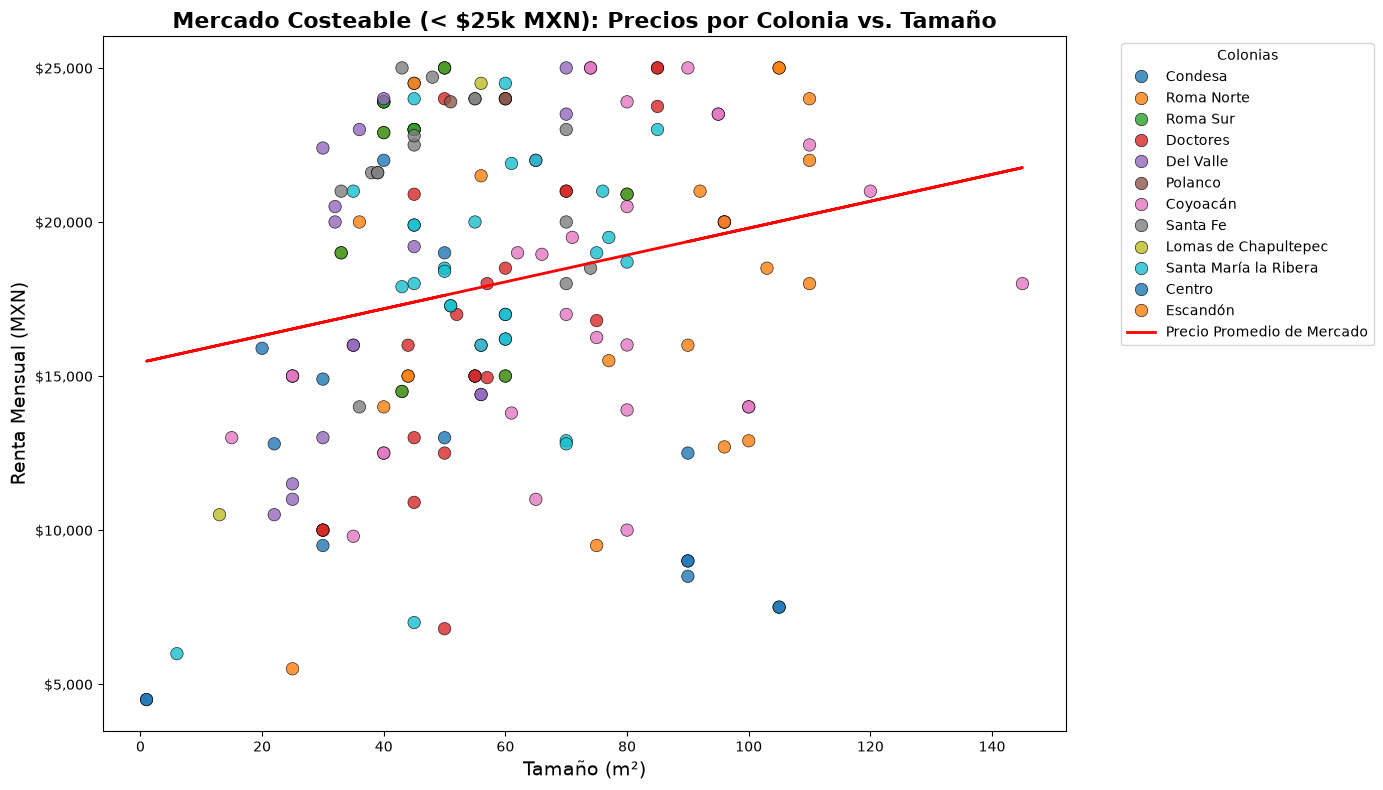

🎯 Se detectaron 57 departamentos subvaluados en el rango accesible.

🏆 TOP 10 DEPARTAMENTOS COSTEABLES:


,colonia,titulo,precio_numerico,precio_esperado,metros_cuadrados,ahorro_mensual
652,Centro,"MN 7,500",7500,20018.33,105,12518.326156
651,Centro,Permite mascotas,7500,20018.33,105,12518.326156
673,Escandón,"MN 5,500",5500,16529.17,25,11029.167828
646,Centro,Amueblado,4500,15482.42,1,10982.420329
647,Centro,"MN 4,500",4500,15482.42,1,10982.420329
643,Centro,"MN 8,500",8500,19364.11,90,10864.108970
191,Doctores,"MN 6,800",6800,17619.53,50,10819.529806
622,Santa María la Ribera,"MN 7,000",7000,17401.46,45,10401.457410
640,Centro,Área de lavado,9000,19364.11,90,10364.108970
641,Centro,"MN 9,000",9000,19364.11,90,10364.108970


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("📈 Fase 6: Análisis de Oportunidades (Presupuesto Accesible)...")

# 1. Filtro estricto: Rentas <= 25,000 MXN y áreas <= 150 m2
df_real = df[(df['precio_numerico'] <= 25000) & (df['metros_cuadrados'] <= 150)].copy()

# 2. Recalculamos la Regresión Lineal SÓLO para este sector realista
m, b = np.polyfit(df_real['metros_cuadrados'], df_real['precio_numerico'], 1)
df_real['precio_esperado'] = (m * df_real['metros_cuadrados']) + b

# 3. Gangas útiles: Propiedades que cuestan al menos $2,500 MXN MENOS de lo esperado
df_real['ahorro_mensual'] = df_real['precio_esperado'] - df_real['precio_numerico']
gangas_reales = df_real[df_real['ahorro_mensual'] > 2500].sort_values(by='ahorro_mensual', ascending=False)

# --- VISUALIZACIÓN MULTICOLOR ---
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_real,
    x='metros_cuadrados',
    y='precio_numerico',
    hue='colonia', 
    palette='tab10', 
    alpha=0.8,
    s=80,  # Puntos un poco más grandes para mejor visibilidad
    edgecolor='black',
    linewidth=0.5
)

# Dibujamos la línea de mercado (Regresión)
plt.plot(df_real['metros_cuadrados'], df_real['precio_esperado'], color='red', linewidth=2, label='Precio Promedio de Mercado')

plt.title('Mercado Costeable (< $25k MXN): Precios por Colonia vs. Tamaño', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño (m²)', fontsize=14)
plt.ylabel('Renta Mensual (MXN)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Colonias')
plt.tight_layout()
plt.show()

# --- TABLA DE LAS MEJORES OPORTUNIDADES ---
print(f"🎯 Se detectaron {len(gangas_reales)} departamentos subvaluados en el rango accesible.")
print("\n🏆 TOP 10 DEPARTAMENTOS COSTEABLES:")

gangas_reales['precio_esperado'] = gangas_reales['precio_esperado'].round(2)
columnas_mostrar = ['colonia', 'titulo', 'precio_numerico', 'precio_esperado', 'metros_cuadrados', 'ahorro_mensual']

display(gangas_reales[columnas_mostrar].head(10))

💎 Fase 6: Análisis de Oportunidades en Zonas Premium...


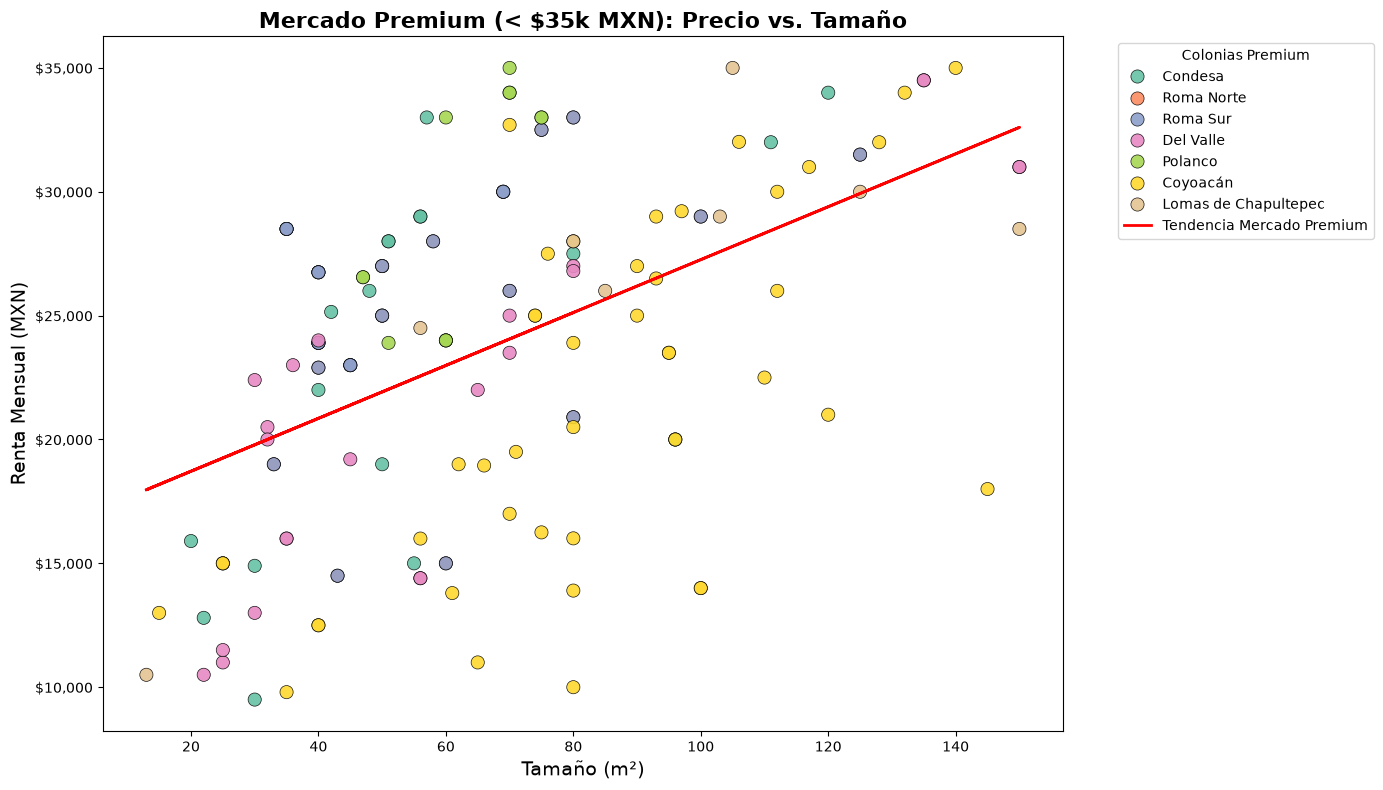

🎯 Se detectaron 49 departamentos subvaluados en el clúster de alto confort.

🏆 TOP 10 DEPARTAMENTOS PREMIUM COSTEABLES:


,colonia,titulo,precio_numerico,precio_esperado,metros_cuadrados,ahorro_mensual
383,Coyoacán,"MN 10,000",10000,25124.93,80,15124.932981
363,Coyoacán,"MN 18,000",18000,32065.59,145,14065.589232
369,Coyoacán,Balcón,14000,27260.52,100,13260.519520
424,Coyoacán,"MN 14,000",14000,27260.52,100,13260.519520
415,Coyoacán,"MN 11,000",11000,23523.24,65,12523.243077
349,Coyoacán,"MN 13,900",13900,25124.93,80,11224.932981
417,Coyoacán,"MN 9,800",9800,20319.86,35,10519.863269
64,Condesa,"MN 9,500",9500,19785.97,30,10285.966634
384,Coyoacán,"MN 13,800",13800,23096.13,61,9296.125769
419,Coyoacán,"MN 16,009",16009,25124.93,80,9115.932981


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("💎 Fase 6: Análisis de Oportunidades en Zonas Premium...")

# 1. Definimos el clúster de alto confort
zonas_premium = [
    'Roma Norte', 'Roma Sur', 'Polanco', 'Coyoacán', 
    'Condesa', 'Lomas de Chapultepec', 'Del Valle'
]

# 2. Filtramos por zonas premium y ajustamos el techo a $35,000 MXN y 150m2
df_premium = df[
    (df['colonia'].isin(zonas_premium)) & 
    (df['precio_numerico'] <= 35000) & 
    (df['metros_cuadrados'] <= 150)
].copy()

# 3. Recalculamos la Regresión Lineal EXCLUSIVA para este clúster
m, b = np.polyfit(df_premium['metros_cuadrados'], df_premium['precio_numerico'], 1)
df_premium['precio_esperado'] = (m * df_premium['metros_cuadrados']) + b

# 4. Gangas Premium: Propiedades al menos $3,000 MXN por debajo del valor esperado
df_premium['ahorro_mensual'] = df_premium['precio_esperado'] - df_premium['precio_numerico']
gangas_premium = df_premium[df_premium['ahorro_mensual'] > 3000].sort_values(by='ahorro_mensual', ascending=False)

# --- VISUALIZACIÓN MULTICOLOR ---
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_premium,
    x='metros_cuadrados',
    y='precio_numerico',
    hue='colonia', 
    palette='Set2', # Cambiamos a una paleta de colores más elegante
    alpha=0.9,
    s=90,
    edgecolor='black',
    linewidth=0.5
)

# Dibujamos la línea del mercado premium
plt.plot(df_premium['metros_cuadrados'], df_premium['precio_esperado'], color='red', linewidth=2, label='Tendencia Mercado Premium')

plt.title('Mercado Premium (< $35k MXN): Precio vs. Tamaño', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño (m²)', fontsize=14)
plt.ylabel('Renta Mensual (MXN)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Colonias Premium')
plt.tight_layout()
plt.show()

# --- TABLA DE LAS MEJORES OPORTUNIDADES ---
print(f"🎯 Se detectaron {len(gangas_premium)} departamentos subvaluados en el clúster de alto confort.")
print("\n🏆 TOP 10 DEPARTAMENTOS PREMIUM COSTEABLES:")

gangas_premium['precio_esperado'] = gangas_premium['precio_esperado'].round(2)
columnas_mostrar = ['colonia', 'titulo', 'precio_numerico', 'precio_esperado', 'metros_cuadrados', 'ahorro_mensual']

display(gangas_premium[columnas_mostrar].head(10))

## Fase 7: Segmentación de Mercado con Machine Learning (K-Means)

🤖 Fase 7: Segmentación de Mercado con Machine Learning (K-Means)...


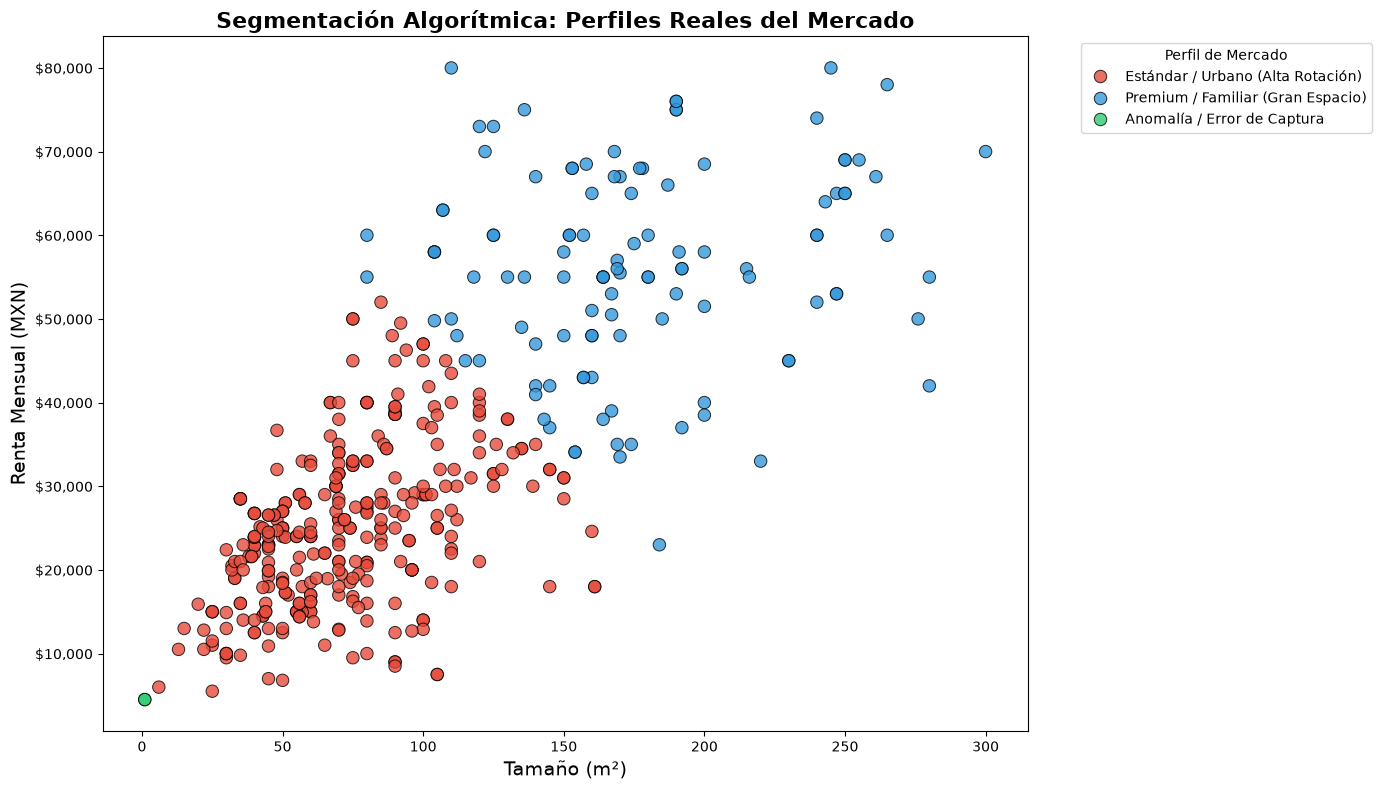


🧠 Radiografía de los Clústeres (Promedios por Perfil):


,precio_numerico,metros_cuadrados,precio_por_m2
perfil_mercado,,,
Anomalía / Error de Captura,4500.00,1.00,4500.00
Estándar / Urbano (Alta Rotación),24989.80,72.12,386.83
Premium / Familiar (Gran Espacio),55977.37,176.28,341.52


In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

print("🤖 Fase 7: Segmentación de Mercado con Machine Learning (K-Means)...")

# 1. Filtramos la base para aislar anomalías matemáticas extremas
df_ml = df[(df['precio_numerico'] <= 80000) & (df['metros_cuadrados'] <= 300)].copy()

# 2. Selección de Variables y Estandarización
features = df_ml[['metros_cuadrados', 'precio_numerico', 'precio_por_m2']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 3. Entrenamiento del Algoritmo (3 Clústeres)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['cluster'] = kmeans.fit_predict(features_scaled)

# 4. Traducción de Negocio (Mapeo de Clústeres)
nombres_clusters = {
    0: "Anomalía / Error de Captura",
    1: "Estándar / Urbano (Alta Rotación)",
    2: "Premium / Familiar (Gran Espacio)"
}
df_ml['perfil_mercado'] = df_ml['cluster'].map(nombres_clusters)

# 5. Visualización
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_ml, 
    x='metros_cuadrados', 
    y='precio_numerico', 
    hue='perfil_mercado', 
    palette=['#E74C3C', '#3498DB', '#2ECC71'], # Rojo, Azul, Verde
    alpha=0.8, 
    s=80, 
    edgecolor='black'
)

plt.title('Segmentación Algorítmica: Perfiles Reales del Mercado', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño (m²)', fontsize=14)
plt.ylabel('Renta Mensual (MXN)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(title='Perfil de Mercado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. Resumen Ejecutivo
print("\n🧠 Radiografía de los Clústeres (Promedios por Perfil):")
resumen = df_ml.groupby('perfil_mercado')[['precio_numerico', 'metros_cuadrados', 'precio_por_m2']].mean().round(2)
display(resumen)

## Fase 8: Inteligencia de Negocio y Metricas clave

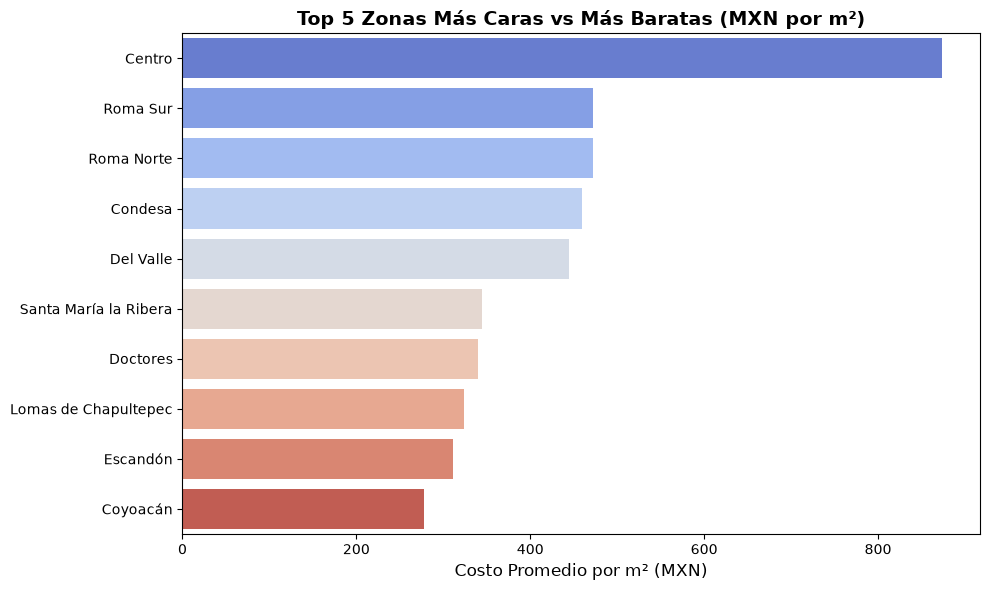

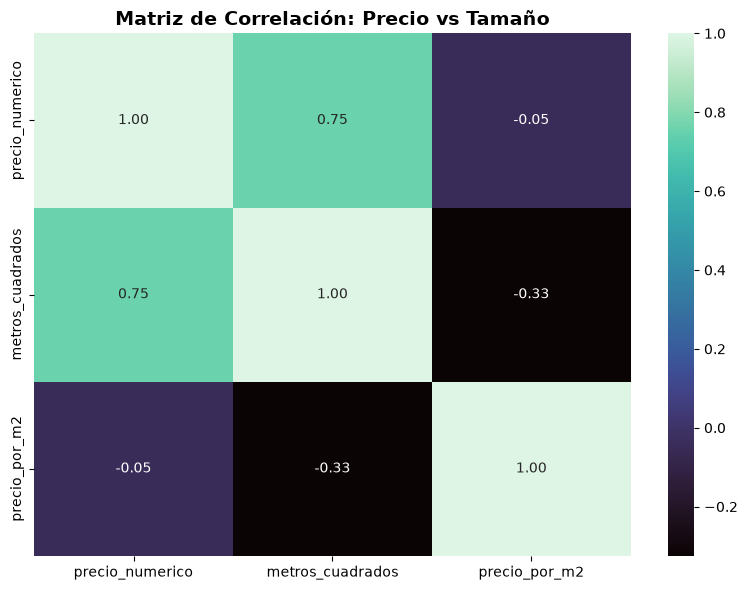

✅ Datos exportados a 'perfiles_mercado.json' listos para integrarse en aplicaciones web.


In [23]:

# --- GRÁFICO 1: Las 5 Colonias más caras vs más baratas por m2 ---
plt.figure(figsize=(10, 6))
costo_m2 = df_ml.groupby('colonia')['precio_por_m2'].mean().sort_values(ascending=False)
top_5_caras = costo_m2.head(5)
top_5_baratas = costo_m2.tail(5)
extremos_m2 = pd.concat([top_5_caras, top_5_baratas])

# Se añade hue=extremos_m2.index y legend=False para cumplir con la nueva sintaxis de Seaborn
sns.barplot(x=extremos_m2.values, y=extremos_m2.index, hue=extremos_m2.index, palette="coolwarm", legend=False)
plt.title('Top 5 Zonas Más Caras vs Más Baratas (MXN por m²)', fontsize=14, fontweight='bold')
plt.xlabel('Costo Promedio por m² (MXN)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Mapa de Calor de Correlaciones ---
plt.figure(figsize=(8, 6))
columnas_numericas = df_ml[['precio_numerico', 'metros_cuadrados', 'precio_por_m2']]
matriz_correlacion = columnas_numericas.corr()

# Se activa la barra de color (cbar=True) para mejor lectura individual
sns.heatmap(matriz_correlacion, annot=True, cmap="mako", fmt=".2f", cbar=True)
plt.title('Matriz de Correlación: Precio vs Tamaño', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- EXPORTACIÓN DE RESULTADOS PARA FRONTEND ---
resumen.reset_index().to_json('perfiles_mercado.json', orient='records', force_ascii=False)
print("✅ Datos exportados a 'perfiles_mercado.json' listos para integrarse en aplicaciones web.")